In [27]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('superstore_sales.csv') 
connection = sqlite3.connect('superstore_analytics.db')
df.to_sql('sales_data', connection, if_exists='replace', index=False)

9800

In [29]:
query_summary = """
SELECT 
    "Category", 
    COUNT("Order ID") AS Total_Orders,
    ROUND(SUM("Sales"), 2) AS Total_Revenue,
    ROUND(AVG("Sales"), 2) AS Average_Order_Value
FROM sales_data
GROUP BY "Category"
ORDER BY Total_Revenue DESC;
"""

executive_summary_df = pd.read_sql_query(query_summary, connection)

In [30]:
query_leaks = """
SELECT 
    "Sub-Category", 
    ROUND(SUM("Sales"), 2) AS Total_Sales
FROM sales_data
GROUP BY "Sub-Category"
ORDER BY Total_Sales ASC
LIMIT 5;
"""

business_leaks_df = pd.read_sql_query(query_leaks, connection)

--- EXECUTIVE SUMMARY ---
       Category  Total_Orders  Total_Revenue  Average_Order_Value
     Technology          1813      827455.87               456.40
      Furniture          2078      728658.58               350.65
Office Supplies          5909      705422.33               119.38

--- BOTTOM 5 PERFORMING ITEMS (BUSINESS LEAKS) ---
Sub-Category  Total_Sales
   Fasteners      3001.96
      Labels     12347.73
   Envelopes     16128.05
         Art     26705.41
    Supplies     46420.31


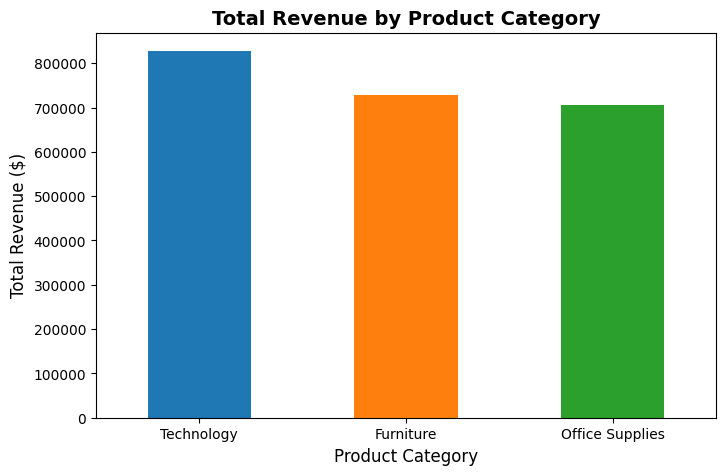

In [31]:
print("--- EXECUTIVE SUMMARY ---")
print(executive_summary_df.to_string(index=False))
print("\n--- BOTTOM 5 PERFORMING ITEMS (BUSINESS LEAKS) ---")
print(business_leaks_df.to_string(index=False))


executive_summary_df.plot(
    kind='bar', 
    x='Category', 
    y='Total_Revenue', 
    color=['#1f77b4', '#ff7f0e', '#2ca02c'], 
    legend=False, 
    figsize=(8, 5)
)
plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=0) 
plt.show()

In [32]:
connection.close()